---
title: CESM2 LENS surface ocean heat content
author: Harsha R. Hampapura
tags:
  - origin:ncar-posix
  - platform:casper
  - dataset:cesm
  - task:visualization
  - level:intermediate
---
# CESM2 LENS surface ocean heat content

[<span class="tag tag-origin">origin:ncar-posix</span>](/tag-index#tag-origin-ncar-posix) [<span class="tag tag-platform">platform:casper</span>](/tag-index#tag-platform-casper) [<span class="tag tag-dataset">dataset:cesm</span>](/tag-index#tag-dataset-cesm) [<span class="tag tag-task">task:visualization</span>](/tag-index#tag-task-visualization) [<span class="tag tag-level">level:intermediate</span>](/tag-index#tag-level-intermediate)

## Calculate surface ocean heat content using CESM2 LENS data
### Table of Contents
- [Section 1: Introduction](#Section-1:-Introduction) 
- [Section 2: Select Dask Cluster](#Section-2:-Select-Dask-Cluster) 
- [Section 3: Data Loading](#Section-3:-Data-Loading) 
- [Section 4: Data Analysis](#Section-4:-Data-Analysis)  

- This notebook is adapted from the NCAR gallery in the Pangeo collection
- https://gallery.pangeo.io/repos/NCAR/notebook-gallery/notebooks/Run-Anywhere/Ocean-Heat-Content/OHC_tutorial.html

## Section 1: Introduction
### Input Data Access

- This notebook illustrates how to compute surface ocean heat content using potential temperature data from CESM2 Large Ensemble Dataset (https://www.cesm.ucar.edu/community-projects/lens2) hosted on NCAR's GDEX.
- This data is open access and is accessed via OSDF

In [7]:
# Imports
import intake
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt

In [8]:
import fsspec.implementations.http as fshttp
from pelicanfs.core import PelicanFileSystem, PelicanMap, OSDFFileSystem 
import cf_units as cf

In [9]:
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client
from dask.distributed import performance_report

In [10]:
init_year0  = '1991'
init_year1  = '2020'
final_year0 = '2071'
final_year1 = '2100'

In [11]:
def to_daily(ds):
    year = ds.time.dt.year
    day = ds.time.dt.dayofyear

    # assign new coords
    ds = ds.assign_coords(year=("time", year.data), day=("time", day.data))

    # reshape the array to (..., "day", "year")
    return ds.set_index(time=("year", "day")).unstack("time")

In [12]:
# Set up your sratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)
#
catalog_url = 'https://osdata.gdex.ucar.edu/d010092/catalogs/d010092-osdf.json'
# catalog_url = 'https://data.gdex.ucar.edu/OS/d010092/catalogs/d010092-https.json'  #NCAR's Object store

/glade/derecho/scratch/harshah


## Section 2: Select Dask Cluster
- Setting up a dask cluster. You will need to choose the type of cluster based on your use case.
- The default will be LocalCluster as that can run on any system.
- If running on NCAR's HPC i.e, Casper with a PBS Scheduler, set USE_PBS_SCHEDULER to True. Otherwise, set to False.

In [13]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name = 'dask-wk24-hpc',
    cores = 1,
    memory = '8GiB',
    processes = 1,
    local_directory = glade_scratch+'/dask/spill',
    log_directory = glade_scratch + '/dask/logs/',
    resource_spec = 'select=1:ncpus=1:mem=8GB',
    queue = 'casper',
    walltime = '5:00:00',
    #interface = 'ib0'
    interface = 'ext'
)

/glade/u/home/harshah/.conda/envs/osdf/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43825 instead
  warnings.warn(


In [15]:
# Create the client to load the Dashboard
client = Client(cluster)

In [16]:
n_workers =5
cluster.scale(n_workers)
client.wait_for_workers(n_workers = n_workers)
cluster

PBSCluster(3b16f8fb, 'tcp://128.117.208.93:46221', workers=5, threads=5, memory=40.00 GiB)

## Section 3: Data Loading
- Load CESM2 LENS zarr data from GDEX using an intake-ESM catalog
- For more details regarding the dataset. See, https://gdex.ucar.edu/datasets/d010092/#

In [17]:
cesm_cat = intake.open_esm_datastore(catalog_url)
cesm_cat

,unique
,322
variable,54
long_name,52
component,4
experiment,2
forcing_variant,2
frequency,3
vertical_levels,4
spatial_domain,3
units,21


In [11]:
# cesm_cat.df['variable'].values

In [18]:
cesm_temp = cesm_cat.search(variable ='TEMP', frequency ='monthly',experiment='historical')
cesm_temp

,unique
column_0,1
variable,1
long_name,1
component,1
experiment,1
forcing_variant,1
frequency,1
vertical_levels,1
spatial_domain,1
units,1


In [19]:
cesm_temp.df['path'].values

<ArrowExtensionArray>
['osdf:///ncar-gdex/d010092/ocn/monthly/cesm2LE-historical-cmip6-TEMP.zarr']
Length: 1, dtype: large_string[pyarrow]

:::{note}: Important Note!
Because our environment has zarr version >= 3 and the zarr stores we are trying to open were created using zarr version <3,
we need to force the use of zarr version 2 by passing keyword arguments to the to_dataset_dict() function
:::

In [20]:
dsets_cesm = cesm_temp.to_dataset_dict(xarray_open_kwargs={'engine':'zarr','backend_kwargs':{'consolidated': True,'zarr_format': 2}})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'component.experiment.frequency.forcing_variant'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:22&lt;00:00]</div>

In [21]:
cesm_temp.keys()

['ocn.historical.monthly.cmip6']

In [22]:
historical       = dsets_cesm['ocn.historical.monthly.cmip6']
# future_smbb      = dsets_cesm['ocn.ssp370.monthly.smbb']
# future_cmip6     = dsets_cesm['ocn.ssp370.monthly.cmip6']

In [23]:
# %%time
# merge_ds_cmip6 = xr.concat([historical, future_cmip6], dim='time')
# merge_ds_cmip6 = merge_ds_cmip6.dropna(dim='member_id')

In [24]:
historical

<xarray.Dataset> Size: 3TB
Dimensions:     (member_id: 50, time: 1980, z_t: 60, nlat: 384, nlon: 320, d2: 2)
Coordinates:
  * member_id   (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time        (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * z_t         (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    time_bound  (time, d2) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon, d2
Data variables:
    TEMP        (member_id, time, z_t, nlat, nlon) float32 3TB dask.array<chunksize=(1, 5, 57, 375, 311), meta=np.ndarray>
Attributes: (12/25)
    Conventions:                       CF-1.0; http://www.cgd.ucar.edu/cms/ea...
    calendar:                          All years have exactly  365 days.
    cell_methods:                      cell_methods = time: mean ==> the vari...
    contents:                          Diagnostic and Prognostic Variables
    model_doi_url:                     https://doi.org/10.5065/D67H1H0V
    revision:                          $Id$
    ...                                ...
    intake_esm_attrs:units:            degC
    intake_esm_attrs:start_time:       1850-01-16 12:00:00
    intake_esm_attrs:end_time:         2014-12-16 12:00:00
    intake_esm_attrs:path:             osdf:///ncar-gdex/d010092/ocn/monthly/...
    intake_esm_attrs:_data_format_:    zarr
    intake_esm_dataset_key:            ocn.historical.monthly.cmip6

#### Change units

In [25]:
orig_units = cf.Unit(historical.z_t.attrs['units'])
orig_units

Unit('centimeters')

In [26]:
def change_units(ds, variable_str, variable_bounds_str, target_unit_str):
    orig_units = cf.Unit(ds[variable_str].attrs['units'])
    target_units = cf.Unit(target_unit_str)
    variable_in_new_units = xr.apply_ufunc(orig_units.convert, ds[variable_bounds_str], target_units, dask='parallelized', output_dtypes=[ds[variable_bounds_str].dtype])
    return variable_in_new_units

In [27]:
historical['z_t']

<xarray.DataArray 'z_t' (z_t: 60)> Size: 240B
array([5.000000e+02, 1.500000e+03, 2.500000e+03, 3.500000e+03, 4.500000e+03,
       5.500000e+03, 6.500000e+03, 7.500000e+03, 8.500000e+03, 9.500000e+03,
       1.050000e+04, 1.150000e+04, 1.250000e+04, 1.350000e+04, 1.450000e+04,
       1.550000e+04, 1.650984e+04, 1.754790e+04, 1.862913e+04, 1.976603e+04,
       2.097114e+04, 2.225783e+04, 2.364088e+04, 2.513702e+04, 2.676542e+04,
       2.854837e+04, 3.051192e+04, 3.268680e+04, 3.510935e+04, 3.782276e+04,
       4.087846e+04, 4.433777e+04, 4.827367e+04, 5.277280e+04, 5.793729e+04,
       6.388626e+04, 7.075633e+04, 7.870025e+04, 8.788252e+04, 9.847059e+04,
       1.106204e+05, 1.244567e+05, 1.400497e+05, 1.573946e+05, 1.764003e+05,
       1.968944e+05, 2.186457e+05, 2.413972e+05, 2.649001e+05, 2.889385e+05,
       3.133405e+05, 3.379793e+05, 3.627670e+05, 3.876452e+05, 4.125768e+05,
       4.375392e+05, 4.625190e+05, 4.875083e+05, 5.125028e+05, 5.375000e+05],
      dtype=float32)
Coordinates:
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Attributes:
    long_name:  depth from surface to midpoint of layer
    positive:   down
    units:      centimeters
    valid_max:  537500.0
    valid_min:  500.0

In [28]:
depth_levels_in_m = change_units(historical, 'z_t', 'z_t', 'm')
hist_temp_in_degK = change_units(historical, 'TEMP', 'TEMP', 'degK')
# fut_cmip6_temp_in_degK = change_units(future_cmip6, 'TEMP', 'TEMP', 'degK')
# fut_smbb_temp_in_degK = change_units(future_smbb, 'TEMP', 'TEMP', 'degK')
#
hist_temp_in_degK  = hist_temp_in_degK.assign_coords(z_t=("z_t", depth_levels_in_m['z_t'].data))
hist_temp_in_degK["z_t"].attrs["units"] = "m"
hist_temp_in_degK

<xarray.DataArray 'TEMP' (member_id: 50, time: 1980, z_t: 60, nlat: 384,
                          nlon: 320)> Size: 3TB
dask.array<transpose, shape=(50, 1980, 60, 384, 320), dtype=float32, chunksize=(1, 5, 57, 375, 311), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * z_t        (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Dimensions without coordinates: nlat, nlon
Attributes:
    cell_methods:  time: mean
    grid_loc:      3111
    long_name:     Potential Temperature
    units:         degC

In [29]:
depth_levels_in_m.isel(z_t=slice(0, -1))

<xarray.DataArray 'z_t' (z_t: 59)> Size: 236B
array([5.0000000e+00, 1.5000000e+01, 2.5000000e+01, 3.5000000e+01,
       4.5000000e+01, 5.5000000e+01, 6.5000000e+01, 7.5000000e+01,
       8.5000000e+01, 9.5000000e+01, 1.0500000e+02, 1.1500000e+02,
       1.2500000e+02, 1.3500000e+02, 1.4500000e+02, 1.5500000e+02,
       1.6509840e+02, 1.7547905e+02, 1.8629128e+02, 1.9766028e+02,
       2.0971138e+02, 2.2257828e+02, 2.3640883e+02, 2.5137016e+02,
       2.6765421e+02, 2.8548364e+02, 3.0511923e+02, 3.2686798e+02,
       3.5109348e+02, 3.7822763e+02, 4.0878464e+02, 4.4337769e+02,
       4.8273672e+02, 5.2772803e+02, 5.7937286e+02, 6.3886261e+02,
       7.0756329e+02, 7.8700250e+02, 8.7882526e+02, 9.8470587e+02,
       1.1062042e+03, 1.2445669e+03, 1.4004972e+03, 1.5739464e+03,
       1.7640033e+03, 1.9689442e+03, 2.1864565e+03, 2.4139717e+03,
       2.6490012e+03, 2.8893848e+03, 3.1334048e+03, 3.3797935e+03,
       3.6276704e+03, 3.8764519e+03, 4.1257681e+03, 4.3753926e+03,
       4.6251904e+03, 4.8750835e+03, 5.1250283e+03], dtype=float32)
Coordinates:
  * z_t      (z_t) float32 236B 500.0 1.5e+03 2.5e+03 ... 4.875e+05 5.125e+05
Attributes:
    long_name:  depth from surface to midpoint of layer
    positive:   down
    units:      centimeters
    valid_max:  537500.0
    valid_min:  500.0

In [30]:
#Compute depth level deltas using z_t levels
depth_level_deltas = depth_levels_in_m.isel(z_t=slice(1, None)).values - depth_levels_in_m.isel(z_t=slice(0, -1)).values
# Optionally, if you want to keep it as an xarray DataArray, re-wrap the result
depth_level_deltas = xr.DataArray(depth_level_deltas, dims=["z_t"], coords={"z_t": depth_levels_in_m.z_t.isel(z_t=slice(0, -1))})
depth_level_deltas                                                                                        

<xarray.DataArray (z_t: 59)> Size: 236B
array([ 10.      ,  10.      ,  10.      ,  10.      ,  10.      ,
        10.      ,  10.      ,  10.      ,  10.      ,  10.      ,
        10.      ,  10.      ,  10.      ,  10.      ,  10.      ,
        10.098404,  10.380646,  10.812225,  11.369003,  12.051102,
        12.866898,  13.830551,  14.961334,  16.284042,  17.829437,
        19.63559 ,  21.748749,  24.225494,  27.134155,  30.557007,
        34.59305 ,  39.35904 ,  44.991302,  51.644836,  59.489746,
        68.70068 ,  79.43921 ,  91.822754, 105.880615, 121.49835 ,
       138.36267 , 155.9303  , 173.44922 , 190.05688 , 204.94092 ,
       217.51233 , 227.51514 , 235.02954 , 240.38354 , 244.02002 ,
       246.38867 , 247.87695 , 248.7815  , 249.31616 , 249.62451 ,
       249.79785 , 249.89307 , 249.94482 , 249.97168 ], dtype=float32)
Coordinates:
  * z_t      (z_t) float32 236B 500.0 1.5e+03 2.5e+03 ... 4.875e+05 5.125e+05

## Section 4: Data Analysis 
#### Compute Ocean Heat content for ocean surface
- Ocean surface is considered to be the top 100m
- The formula for this is: $$ H = \rho C \int_0^z T(z) dz $$


Where H is ocean heat content, the value we are trying to calculate,

$\rho$ is the density of sea water, $1026 kg/m^3$  ,

$C$ is the specific heat of sea water, $3990 J/(kg K)$  ,

$z$ is the depth limit of the calculation in meters,

and $T(z)$ is the temperature at each depth in degrees Kelvin.

In [31]:
def calc_ocean_heat(delta_level, temperature):
    rho = 1026 #kg/m^3
    c_p = 3990 #J/(kg K)
    weighted_temperature = delta_level * temperature
    heat = weighted_temperature.sum(dim="z_t")*rho*c_p
    return heat

In [32]:
# Remember that the coordinate z_t still has values in cm
hist_temp_ocean_surface = hist_temp_in_degK.where(hist_temp_in_degK['z_t'] < 1e4,drop=True)
hist_temp_ocean_surface

<xarray.DataArray 'TEMP' (member_id: 50, time: 1980, z_t: 10, nlat: 384,
                          nlon: 320)> Size: 487GB
dask.array<where, shape=(50, 1980, 10, 384, 320), dtype=float32, chunksize=(1, 5, 10, 375, 311), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
  * z_t        (z_t) float32 40B 500.0 1.5e+03 2.5e+03 ... 8.5e+03 9.5e+03
Dimensions without coordinates: nlat, nlon
Attributes:
    cell_methods:  time: mean
    grid_loc:      3111
    long_name:     Potential Temperature
    units:         degC

In [33]:
depth_level_deltas_surface = depth_level_deltas.where(depth_level_deltas['z_t'] <1e4, drop= True)
depth_level_deltas_surface

<xarray.DataArray (z_t: 10)> Size: 40B
array([10., 10., 10., 10., 10., 10., 10., 10., 10., 10.], dtype=float32)
Coordinates:
  * z_t      (z_t) float32 40B 500.0 1.5e+03 2.5e+03 ... 7.5e+03 8.5e+03 9.5e+03

In [34]:
hist_ocean_heat = calc_ocean_heat(depth_level_deltas_surface,hist_temp_ocean_surface)
hist_ocean_heat

<xarray.DataArray (member_id: 50, time: 1980, nlat: 384, nlon: 320)> Size: 49GB
dask.array<mul, shape=(50, 1980, 384, 320), dtype=float32, chunksize=(1, 5, 375, 311), chunktype=numpy.ndarray>
Coordinates:
  * member_id  (member_id) <U12 2kB 'r10i1181p1f1' ... 'r9i1301p1f1'
  * time       (time) object 16kB 1850-01-16 12:00:00 ... 2014-12-16 12:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    cell_methods:  time: mean
    grid_loc:      3111
    long_name:     Potential Temperature
    units:         degC

### Plot Ocean Heat

In [35]:
%%time
# Jan, 1850 average over all memebers
# hist_ocean_avgheat = hist_ocean_heat.mean('member_id')
hist_ocean_avgheat = hist_ocean_heat.isel({'time':[0,-12]}).mean('member_id')
hist_ocean_avgheat

CPU times: user 39.6 ms, sys: 3.67 ms, total: 43.3 ms
Wall time: 42.9 ms


<xarray.DataArray (time: 2, nlat: 384, nlon: 320)> Size: 983kB
dask.array<mean_agg-aggregate, shape=(2, 384, 320), dtype=float32, chunksize=(2, 375, 311), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16B 1850-01-16 12:00:00 2014-01-16 12:00:00
Dimensions without coordinates: nlat, nlon
Attributes:
    cell_methods:  time: mean
    grid_loc:      3111
    long_name:     Potential Temperature
    units:         degC

/glade/u/home/harshah/.conda/envs/osdf/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 14.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 11.5 s, sys: 687 ms, total: 12.2 s
Wall time: 1min 30s


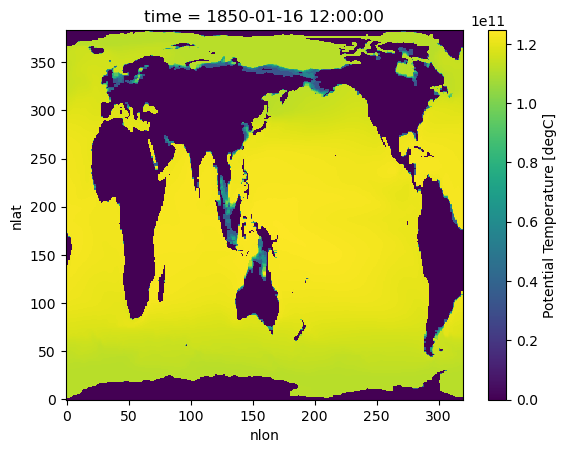

In [36]:
%%time
hist_ocean_avgheat.isel(time=0).plot()

CPU times: user 11.5 s, sys: 455 ms, total: 12 s
Wall time: 1min 3s


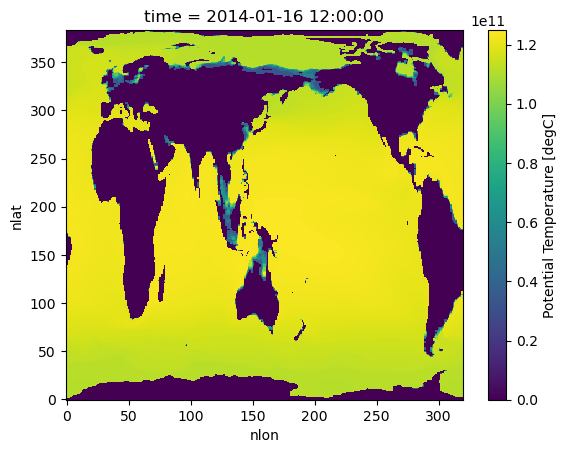

In [37]:
%%time
#Plot ocean heat for Jan 2014
hist_ocean_avgheat.isel(time=1).plot()

### Has the surface ocean heat content increased with time for January ? (Due to Global Warming!)

In [38]:
hist_ocean_avgheat_ano = hist_ocean_avgheat.isel(time=1) - hist_ocean_avgheat.isel(time=0)

/glade/u/home/harshah/.conda/envs/osdf/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 14.27 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 10.9 s, sys: 344 ms, total: 11.2 s
Wall time: 1min 1s


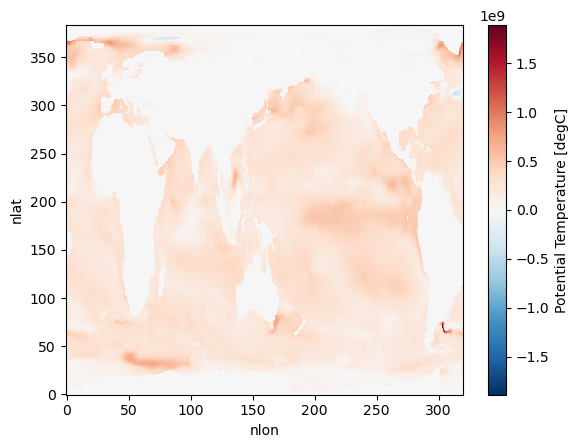

In [39]:
%%time
hist_ocean_avgheat_ano.plot()

In [40]:
cluster.close()